In [4]:
import kagglehub
import pandas as pd
import numpy as np
import os

try:
    path = kagglehub.dataset_download("chethuhn/network-intrusion-dataset")
    data = pd.read_csv(os.path.join(path, 'Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv'))
    print(" Path to dataset files:", path)
    
except Exception as e:
    print(f"Something failed... {e}")

data.head()

 Path to dataset files: /Users/antoniogonzalez/.cache/kagglehub/datasets/chethuhn/network-intrusion-dataset/versions/1


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [5]:
from sklearn.preprocessing import LabelEncoder

data.columns = data.columns.str.strip()

le = LabelEncoder()


data['Label'] = le.fit_transform(data['Label'])

data.replace([np.inf, -np.inf], np.nan, inplace=True)
data.dropna(inplace=True)

X = data.drop('Label', axis=1)
y = data['Label']

In [6]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=1)

X_train_t = torch.FloatTensor(X_train)
X_test_t = torch.FloatTensor(X_test)
y_train_t = torch.LongTensor(y_train.values)
y_test_t = torch.LongTensor(y_test.values)

class NeuralNet(nn.Module):
    def __init__(self, input_size, num_classes):
        super(NeuralNet, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )
    def forward(self, x):
        return self.layers(x)
    

input_size = X_train_t.shape[1]
num_classes = len(y.unique())
model = NeuralNet(input_size, num_classes)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

dataset = TensorDataset(X_train_t, y_train_t)
loader = DataLoader(dataset, batch_size=512, shuffle=True)

for epoch in range(10):
    for X_batch, y_batch in loader:
        optimizer.zero_grad()
        output = model(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()
    print(f'Epoch {epoch+1}/10 Loss: {loss.item():.4f}')


    model.eval()
    with torch.no_grad():
        y_pred = model(X_test_t).argmax(dim=1).numpy()

    print(classification_report(y_test, y_pred))

Epoch 1/10 Loss: 0.0094
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19563
           1       1.00      1.00      1.00     25580

    accuracy                           1.00     45143
   macro avg       1.00      1.00      1.00     45143
weighted avg       1.00      1.00      1.00     45143

Epoch 2/10 Loss: 0.0038
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19563
           1       1.00      1.00      1.00     25580

    accuracy                           1.00     45143
   macro avg       1.00      1.00      1.00     45143
weighted avg       1.00      1.00      1.00     45143

Epoch 3/10 Loss: 0.0004
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19563
           1       1.00      1.00      1.00     25580

    accuracy                           1.00     45143
   macro avg       1.00      1.00      1.00     45143
we

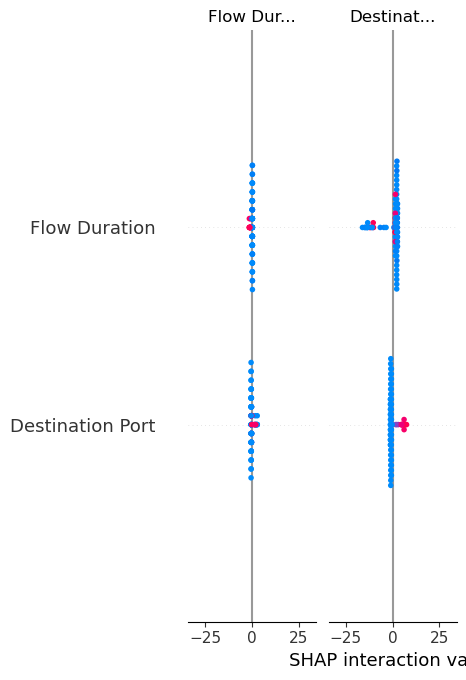

In [7]:
import matplotlib.pyplot as plt
import shap

#  Use '.to('cpu')' to return the data from the (Apple Silicon) GPU back to the CPU
model.to('cpu')
X_train_cpu = X_train_t[:100].to("cpu")
X_test_cpu = X_test_t[:100].to('cpu')
explainer = shap.DeepExplainer(model, X_train_cpu)
shap_values = explainer.shap_values(X_test_cpu)
shap.summary_plot(shap_values, X_test[:100], feature_names=X.columns, class_names=le.classes_)